# **Downloading the required libraries and extensions**

In [ ]:
!pip install gradio plotly

# **Importing the libraries and extensions**

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import gradio as gr
import plotly.express as px

# **Processing the dataset**

In [ ]:
df = pd.read_csv("employee_survey_data.csv")

print(df.columns)
print('\n')

print (df.head())
print('\n')

df.info()
print('\n')

df.describe()
print('\n')

Index(['EmployeeID', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance'],
      dtype='object')


   EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
0           1                      3.0              4.0              2.0
1           2                      3.0              2.0              4.0
2           3                      2.0              2.0              1.0
3           4                      4.0              4.0              3.0
4           5                      4.0              1.0              3.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: floa

In [ ]:
for col in ["EnvironmentSatisfaction", "JobSatisfaction", "WorkLifeBalance"]:
    print(col, "unique values:", sorted(df[col].dropna().unique()))


EnvironmentSatisfaction unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
JobSatisfaction unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
WorkLifeBalance unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


In [ ]:
df.isnull().sum()

,0
EmployeeID,0
EnvironmentSatisfaction,25
JobSatisfaction,20
WorkLifeBalance,38


In [ ]:
cols = ["EnvironmentSatisfaction", "JobSatisfaction", "WorkLifeBalance"]
df[cols] = df[cols].fillna(df[cols].median())
df.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


In [ ]:
df.duplicated(subset="EmployeeID").sum()

# Remove duplicates if any
df = df.drop_duplicates(subset="EmployeeID")


In [ ]:
for col in cols:
    df = df[df[col].between(1, 5)]


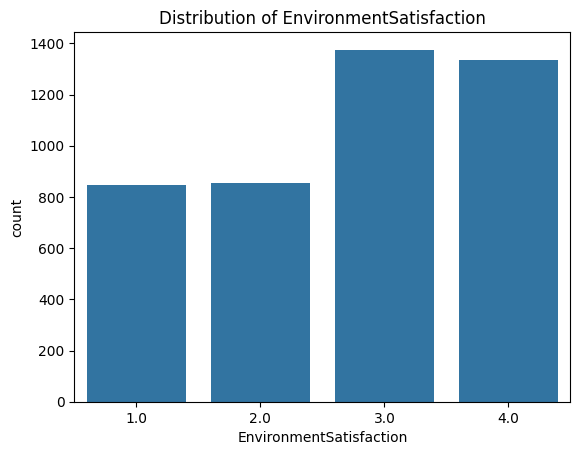

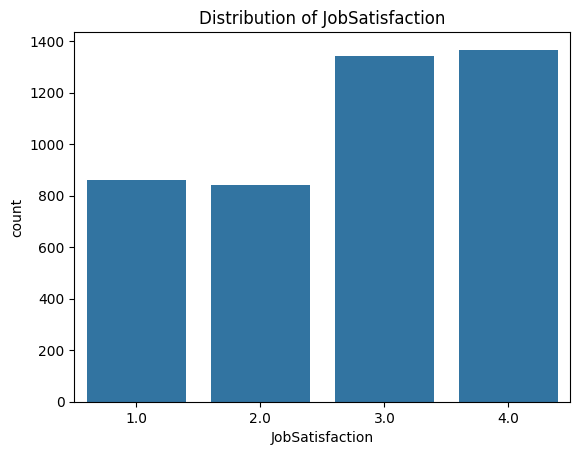

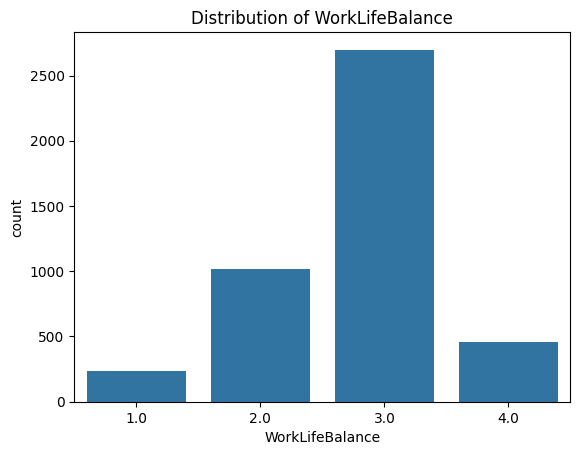

In [ ]:
for col in cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()


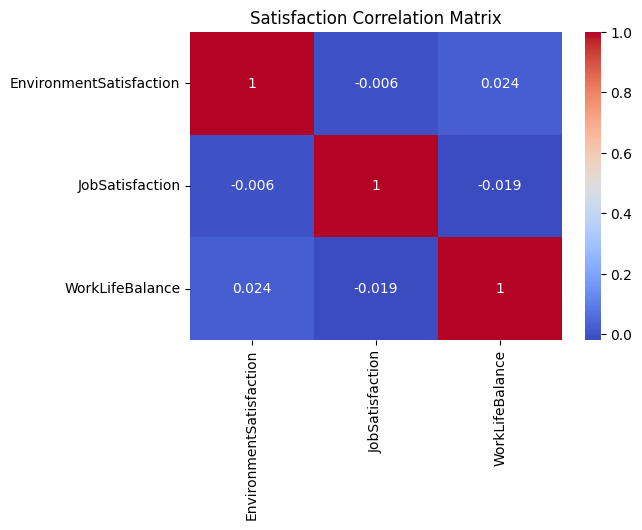

In [ ]:
corr = df[cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Satisfaction Correlation Matrix")
plt.show()


In [ ]:
scaler = MinMaxScaler()
df_norm = df.copy()

df_norm[cols] = scaler.fit_transform(df_norm[cols])


In [ ]:
def sentiment_label(value):
    if value >= 4:
        return "Positive"
    elif value <= 2:
        return "Neutral"
    else:
        return "Negative"

for col in cols:
    df[f"{col}_Sentiment"] = df[col].apply(sentiment_label)


In [ ]:
# Weights (can be adjusted)
weights = {
    "EnvironmentSatisfaction": 0.2,
    "JobSatisfaction": 0.45,
    "WorkLifeBalance": 0.35
}

df["SentimentScore"] = (
    df["EnvironmentSatisfaction"] * weights["EnvironmentSatisfaction"] +
    df["JobSatisfaction"] * weights["JobSatisfaction"] +
    df["WorkLifeBalance"] * weights["WorkLifeBalance"]
)


In [ ]:
def overall_sentiment(score):
    if score >= 2:
        return "Positive"
    elif score == 2:
        return "Neutral"
    else:
        return "Negative"

df["OverallSentiment"] = df["SentimentScore"].apply(overall_sentiment)


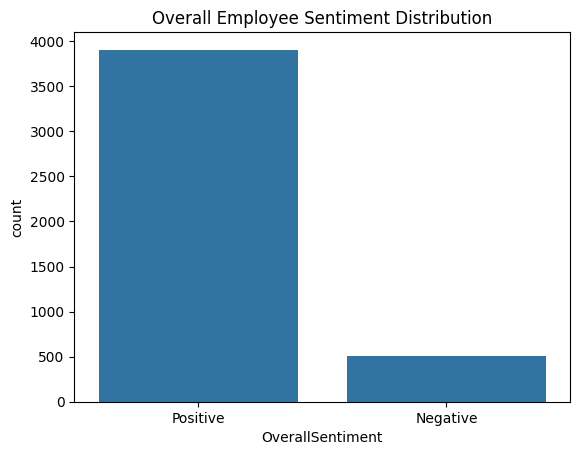

In [ ]:
plt.figure()
sns.countplot(x=df["OverallSentiment"])
plt.title("Overall Employee Sentiment Distribution")
plt.show()


In [ ]:
# Employees with negative sentiment
high_risk_employees = df[df["OverallSentiment"] == "Positive"]

high_risk_employees.head()


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction_Sentiment,JobSatisfaction_Sentiment,WorkLifeBalance_Sentiment,SentimentScore,OverallSentiment
155,156,4.0,4.0,4.0,Positive,Positive,Positive,4.0,Positive
196,197,4.0,4.0,4.0,Positive,Positive,Positive,4.0,Positive
239,240,4.0,4.0,4.0,Positive,Positive,Positive,4.0,Positive
497,498,4.0,4.0,4.0,Positive,Positive,Positive,4.0,Positive
538,539,4.0,4.0,4.0,Positive,Positive,Positive,4.0,Positive


In [ ]:
# Employees with negative sentiment
high_risk_employees = df[df["OverallSentiment"] == "Negative"]

high_risk_employees.head()


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction_Sentiment,JobSatisfaction_Sentiment,WorkLifeBalance_Sentiment,SentimentScore,OverallSentiment
2,3,2.0,2.0,1.0,Neutral,Neutral,Negative,1.65,Negative
6,7,1.0,3.0,1.0,Negative,Negative,Negative,1.90,Negative
9,10,2.0,1.0,3.0,Neutral,Negative,Negative,1.90,Negative
13,14,1.0,2.0,2.0,Negative,Neutral,Neutral,1.80,Negative
19,20,1.0,1.0,3.0,Negative,Negative,Negative,1.70,Negative


In [ ]:

X = df[cols]

kmeans = KMeans(n_clusters=3, random_state=42)
df["SentimentCluster"] = kmeans.fit_predict(X)
print(kmeans)

KMeans(n_clusters=3, random_state=42)


In [ ]:
final_columns = [
    "EmployeeID",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "WorkLifeBalance",
    "SentimentScore",
    "OverallSentiment"
]

final_df = df[final_columns]
final_df.head()


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,SentimentScore,OverallSentiment
0,1,3.0,4.0,2.0,3.10,Neutral
1,2,3.0,2.0,4.0,2.90,Neutral
2,3,2.0,2.0,1.0,1.65,Negative
3,4,4.0,4.0,3.0,3.65,Neutral
4,5,4.0,1.0,3.0,2.30,Neutral


In [ ]:
sentiment_counts = df["OverallSentiment"].value_counts().reset_index()
sentiment_counts.columns = ["Sentiment", "Count"]

fig = px.pie(sentiment_counts, values="Count", names="Sentiment", title="Employee Sentiment Distribution",hole=0.4)
fig.show()